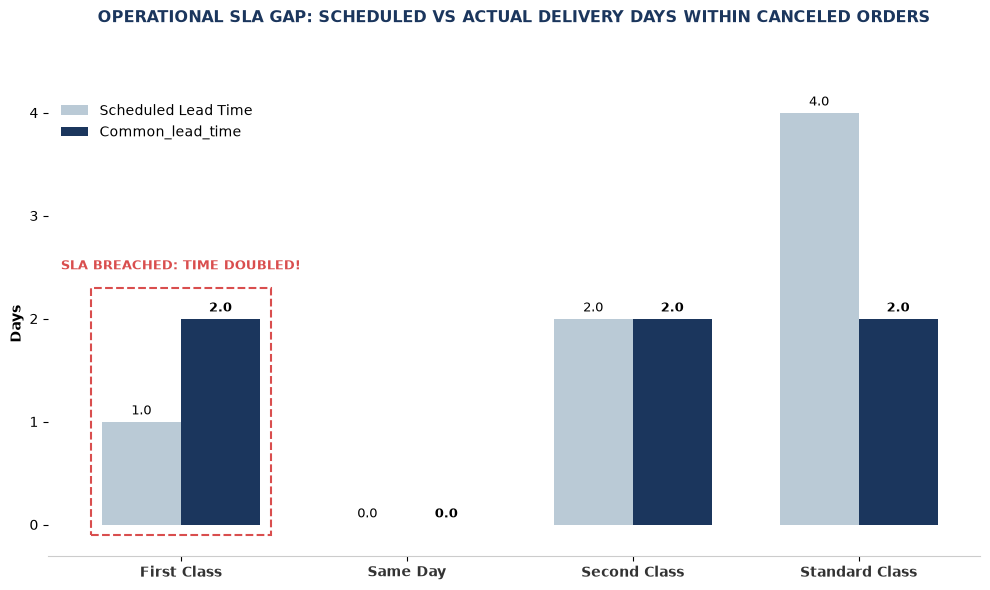

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from analysis import get_shipping_analysis


# 1. Chuẩn bị dữ liệu từ Mục 3 (Shipping Lead Time)
df = get_shipping_analysis()

df_sla = df.reindex(columns=["Shipping Mode", "frequent_actual", "scheduled_lead_time"]).rename(columns={"frequent_actual": "Common_lead_time", "scheduled_lead_time": "Scheduled Time"})



x = np.arange(len(df_sla["Shipping Mode"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Vẽ cặp cột cam kết và thực tế
rects1 = ax.bar(x - width/2, df_sla["Scheduled Time"], width, label="Scheduled Lead Time", color="#BACAD6")
rects2 = ax.bar(x + width/2, df_sla["Common_lead_time"], width, label="Common_lead_time", color="#1B365D")

# Highlight riêng khu vực First Class bằng một khung nét đứt (Pre-attentive attribute: Enclosure)
rect = plt.Rectangle((-0.4, -0.1), 0.8, 2.4, fill=False, edgecolor="#D94E4E", linestyle="--", linewidth=1.5)
ax.add_patch(rect)
ax.text(0, 2.45, "SLA BREACHED: TIME DOUBLED!", ha="center", va="bottom", color="#D94E4E", fontsize=9, fontweight="bold")

# Định dạng trục và chữ
ax.set_title("OPERATIONAL SLA GAP: SCHEDULED VS ACTUAL DELIVERY DAYS WITHIN CANCELED ORDERS", fontsize=11.5, fontweight="bold", color="#1B365D", pad=50)
ax.set_xticks(x)
ax.set_xticklabels(df_sla["Shipping Mode"], fontsize=10, fontweight="bold", color="#333333")
ax.set_ylabel("Days", fontsize=10, fontweight="bold")
ax.legend(frameon=False, loc="upper left")

# Làm sạch viền
for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

# Thêm số liệu trên đỉnh cột
ax.bar_label(rects1, padding=3, fmt="%.1f", fontsize=9)
ax.bar_label(rects2, padding=3, fmt="%.1f", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()



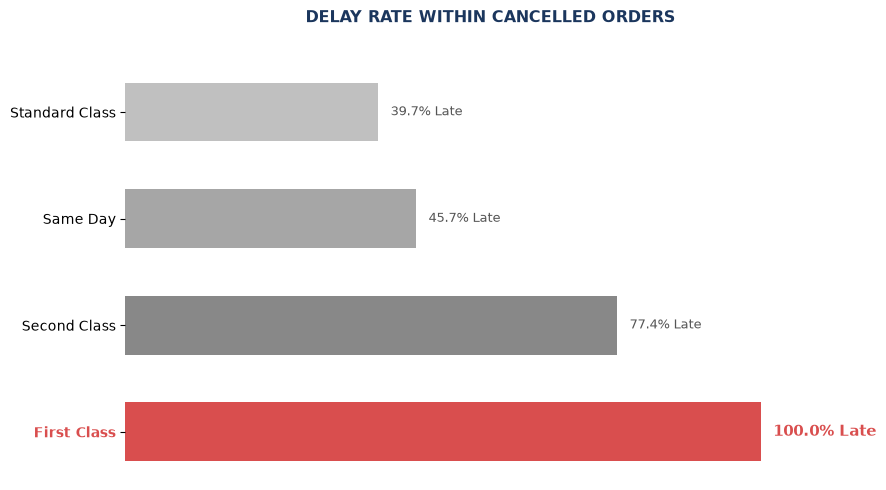

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from analysis import get_cancellation_analysis

total_cont, is_late_df = get_cancellation_analysis()

is_late_df = is_late_df.loc[is_late_df.is_late != 0, :]

df = (pd.merge(is_late_df, total_cont, how="inner", on="Shipping Mode")).assign(Delay_Rate_In_Cancelled = lambda x: x["count"]/x["Total_contribution"]).reindex(columns=["Shipping Mode", "Delay_Rate_In_Cancelled"]).sort_values("Delay_Rate_In_Cancelled", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Mảng màu nhận thức vô thức: Chỉ đỏ rực cho đối tượng mục tiêu, còn lại dìm xuống xám
PRE_ATTENTIVE_COLORS = ["#D94E4E", "#888888", "#A6A6A6", "#C0C0C0"]

bars = ax.barh(df["Shipping Mode"], df["Delay_Rate_In_Cancelled"], color=PRE_ATTENTIVE_COLORS, height=0.55)

# Cấu hình tiêu đề và nhãn xuôi
ax.set_title("DELAY RATE WITHIN CANCELLED ORDERS", fontsize=11.5, fontweight="bold", color="#1B365D", pad=30)
ax.get_xaxis().set_visible(False)

# Format nhãn Y trục
for i, label in enumerate(ax.get_yticklabels()):
    label.set_fontsize(10)
    if i == 0:  # First Class
        label.set_fontweight("bold")
        label.set_color("#D94E4E")

# Thêm nhãn dữ liệu bóc tách
for i, bar in enumerate(bars):
    width = bar.get_width()
    text_weight = "bold" if i == 0 else "normal"
    text_color = "#D94E4E" if i == 0 else "#555555"
    text_size = 11 if i == 0 else 9
    
    ax.text(
        width + 0.02, bar.get_y() + bar.get_height()/2, 
        f"{width*100:.1f}% Late", 
        ha="left", va="center", fontsize=text_size, fontweight=text_weight, color=text_color
    )

# Xóa viền bám đám đông
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xlim(0, 1.15)

plt.tight_layout()
plt.show()



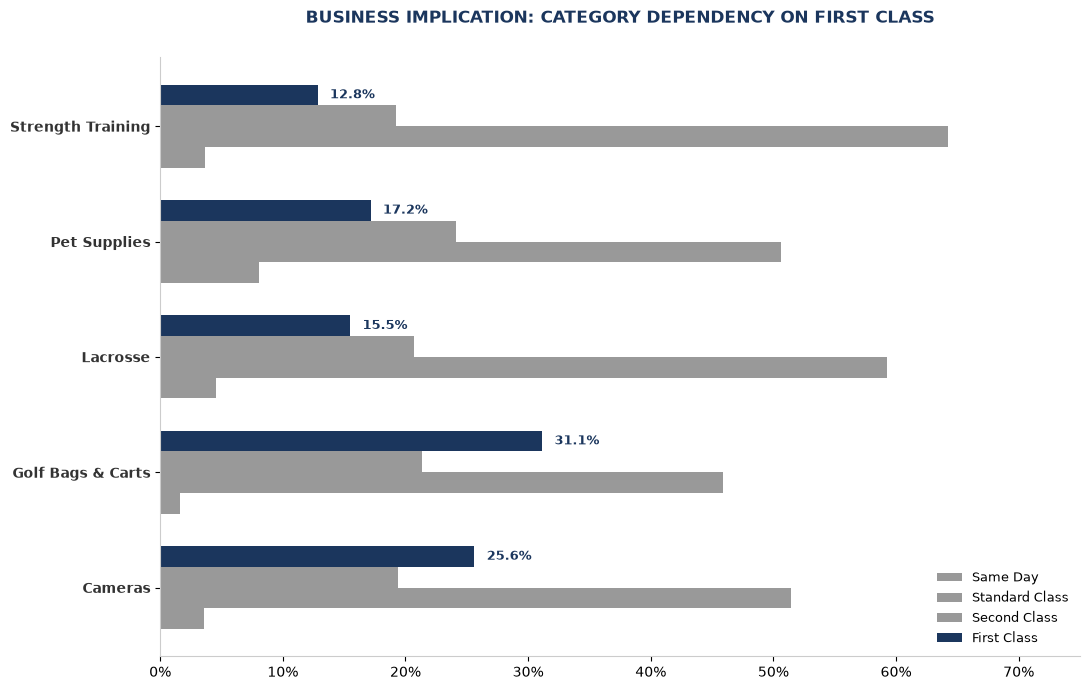

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_category = {
    "Category Name": ["Cameras", "Golf Bags & Carts", "Lacrosse", "Pet Supplies", "Strength Training"],
    "First Class": [0.256228, 0.311475, 0.155015, 0.171610, 0.128440],
    "Same Day": [0.035587, 0.016393, 0.045593, 0.080508, 0.036697],
    "Second Class": [0.193950, 0.213115, 0.206687, 0.241525, 0.192661],
    "Standard Class": [0.514235, 0.459016, 0.592705, 0.506356, 0.642202]
}
df_cat = pd.DataFrame(data_category)

categories = df_cat["Category Name"].unique()
y_indices = np.arange(len(categories))
bar_height = 0.18

fig, ax = plt.subplots(figsize=(11, 7), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Palette màu theo chỉ định: First Class đậm đà, các class khác xám tối
PALETTE_DARK_GRAY = {
    "Same Day": "#999999",     # Navy đậm rực rỡ quyền lực
    "Standard Class": "#999999",        # Xám than tối
    "Second Class": "#1B365D",    # Xám vừa
    "First Class": "#1B365D"   # Xám sáng nhẹ
}

for i, mode in enumerate(["Same Day" ,"Standard Class", "Second Class", "First Class"]):
    offsets = y_indices - (4 * bar_height)/2 + i * bar_height + bar_height/2
    lengths = df_cat[mode].values
    
    bars = ax.barh(offsets, lengths, height=bar_height, color=PALETTE_DARK_GRAY[mode], edgecolor="none")
    
    # Chỉ hiển thị Data Label cho First Class để người xem tập trung tuyệt đối
    if mode == "First Class":
        for j, bar in enumerate(bars):
            val = bar.get_width()
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val*100:.1f}%", 
                    ha="left", va="center", fontsize=9, fontweight="bold", color="#1B365D")

ax.set_title("BUSINESS IMPLICATION: CATEGORY DEPENDENCY ON FIRST CLASS", fontsize=12, fontweight="bold", color="#1B365D", pad=25)
ax.set_yticks(y_indices)
ax.set_yticklabels(categories, fontsize=10, fontweight="bold", color="#333333")
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x*100)}%"))

# Làm sạch không gian viền
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.set_xlim(0, 0.75)

# Thêm chú thích nhóm màu công sở
ax.legend(PALETTE_DARK_GRAY.keys(), loc="best", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()